# 🎯 Corner Kick Modeling: Two-Stage Hierarchical XGBoost Architecture

In this experiment, we explore, analyze, and model **Corner Kicks** across the World Cup dataset using a specialized **Two-Stage Tree-Based Framework**:
1. **Exploratory Data Analysis (EDA) & Pattern Identification**: Uncovering spatial crossing geometries, routine frequencies, and scoring conversion rates.
2. **Feature Extraction & Importance Analysis**: Identifying the critical physical, technical, and tactical drivers of corner kick outcomes.
3. **Two-Stage Model Training**:
   - **Stage 1**: 3-Class XGBoost Routine Classifier (`Direct Central Cross`, `Post Cross`, `Short Corner`).
   - **Stage 2**: Binary XGBoost Outcome Classifier (`Attacking Success` vs. `Defensive Success`).
4. **Stochastic Simulation & Accuracy Evaluation**: Simulating corner routines and outcomes to evaluate predictive performance.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Setup complete. Loading Corner Training Data...
Total Corner Kick Records Loaded: 38659

📊 EMPIRICAL CORNER ROUTINE SUMMARY TABLE


,routine_label,count,success_rate,avg_taker_accuracy,avg_time_ratio,percentage
2,Short Corner Routine,25019,2.1%,80.5%,0.52,64.7%
0,Direct Central Box (Z_5_2),8872,19.6%,77.9%,0.52,22.9%
1,Post Crosses (Z_5_1 / Z_5_3),4768,11.2%,78.8%,0.53,12.3%


/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_64395/875657704.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


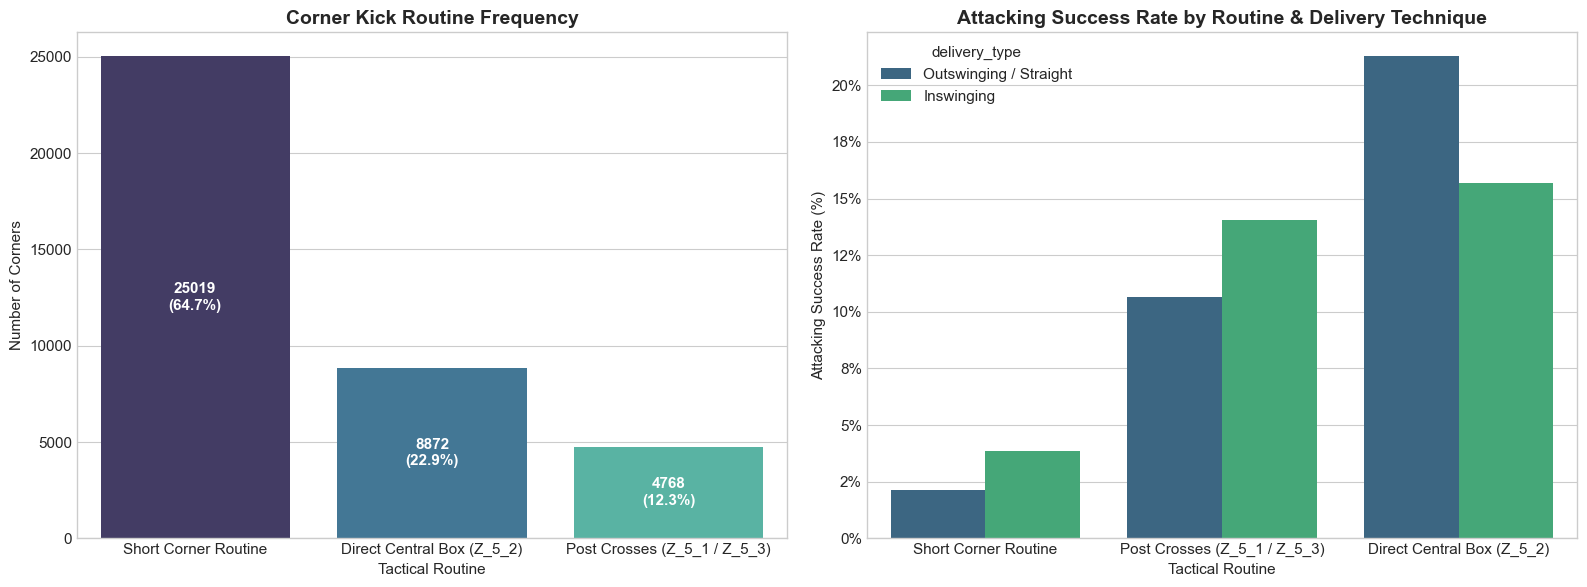

In [26]:
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in path for module imports
if os.getcwd().endswith("experiments"):
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from ml_model.corners.features import extract_corner_features
from ml_model.corners.models import CornerRoutineXGB, CornerOutcomeXGB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report, confusion_matrix, f1_score

# Set sleek visual style for plots
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

print("✅ Setup complete. Loading Corner Training Data...")

# Extract / Load Corner Training Data
data_path = "data/corners_training_data_production.csv"
if not os.path.exists(data_path):
    data_path = "data/corners_training_data_production.csv"
if not os.path.exists(data_path):
    print("Extracting corner features from raw StatsBomb events...")
    df_corners = extract_corner_features(mode="iteration")
else:
    df_corners = pd.read_csv(data_path)

print(f"Total Corner Kick Records Loaded: {len(df_corners)}")

# Map routine target to readable labels
routine_map = {
    0: "Direct Central Box (Z_5_2)",
    1: "Post Crosses (Z_5_1 / Z_5_3)",
    2: "Short Corner Routine"
}
df_corners["routine_label"] = df_corners["target_routine"].map(routine_map)

# Map outcome target to readable labels
outcome_map = {
    1: "Attacking Success (Shot/Goal/Duel Won)",
    0: "Defensive Success (Clearance/Catch/Incomplete)"
}
df_corners["outcome_label"] = df_corners["target_outcome"].map(outcome_map)

# Display Summary Table
routine_summary = df_corners.groupby("routine_label").agg(
    count=("target_routine", "count"),
    success_rate=("target_outcome", "mean"),
    avg_taker_accuracy=("taker_accuracy", "mean"),
    avg_time_ratio=("time_ratio", "mean")
).reset_index()

routine_summary["percentage"] = (routine_summary["count"] / len(df_corners)) * 100
routine_summary = routine_summary.sort_values(by="count", ascending=False)

print("\n" + "="*60)
print("📊 EMPIRICAL CORNER ROUTINE SUMMARY TABLE")
print("="*60)
display(routine_summary.style.format({
    "success_rate": "{:.1%}",
    "avg_taker_accuracy": "{:.1%}",
    "avg_time_ratio": "{:.2f}",
    "percentage": "{:.1f}%"
}))

# Visualizing Corner Patterns (Routines & Technique vs Outcome)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Routine Frequency & Success Rate
ax1 = sns.barplot(
    data=routine_summary,
    x="routine_label",
    y="count",
    palette="mako",
    ax=axes[0]
)
axes[0].set_title("Corner Kick Routine Frequency")
axes[0].set_xlabel("Tactical Routine")
axes[0].set_ylabel("Number of Corners")
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}\n({p.get_height()/len(df_corners):.1%})", 
                 (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                 ha='center', va='center', color='white', fontweight='bold')

# Plot 2: Inswinging vs Outswinging Success Rate by Routine
df_corners["delivery_type"] = df_corners["inswinging"].map({1: "Inswinging", 0: "Outswinging / Straight"})
sns.barplot(
    data=df_corners,
    x="routine_label",
    y="target_outcome",
    hue="delivery_type",
    palette="viridis",
    ax=axes[1],
    errorbar=None
)
axes[1].set_title("Attacking Success Rate by Routine & Delivery Technique")
axes[1].set_xlabel("Tactical Routine")
axes[1].set_ylabel("Attacking Success Rate (%)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

## 🔍 Part 2: Feature Importance Analysis

To understand what drives the decision of *where* to kick the ball (Routine) and *what* happens when it lands (Outcome), we analyze feature importance from our tree-based models. 

We evaluate 18 core domain features:
* **Technical & Specialist**: `taker_accuracy`, `taker_key_pass_ratio`, `inswinging`, `taker_corner_assist_rate`, `delivery_curve_match`
* **Tactical & History**: `team_directness`, `team_width`, `is_right_corner`, `prev_corner_routine_in_match`, `corner_cluster_density`
* **Physical & Defensive**: `opp_gk_save_ratio`, `opp_def_rate`, `under_pressure`, `aerial_height_advantage`, `goalkeeper_line_command`
* **Game Context**: `time_ratio`, `score_differential`, `is_home_team`


🔍 COMBINED XGBOOST FEATURE IMPORTANCE (GAIN)


,Feature,Routine_Importance,Outcome_Importance
0,inswinging,0.6532,0.1009
1,prev_corner_routine_in_match,0.1114,0.2026
2,corner_cluster_density,0.0730,0.1589
3,under_pressure,0.0356,0.0867
4,is_right_corner,0.0265,0.0449
5,taker_corner_assist_rate,0.0212,0.0573
6,taker_accuracy,0.0165,0.0429
7,delivery_curve_match,0.0127,0.0255
8,taker_key_pass_ratio,0.0117,0.0426
9,team_directness,0.0061,0.0334


/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_64395/3475896531.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_64395/3475896531.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


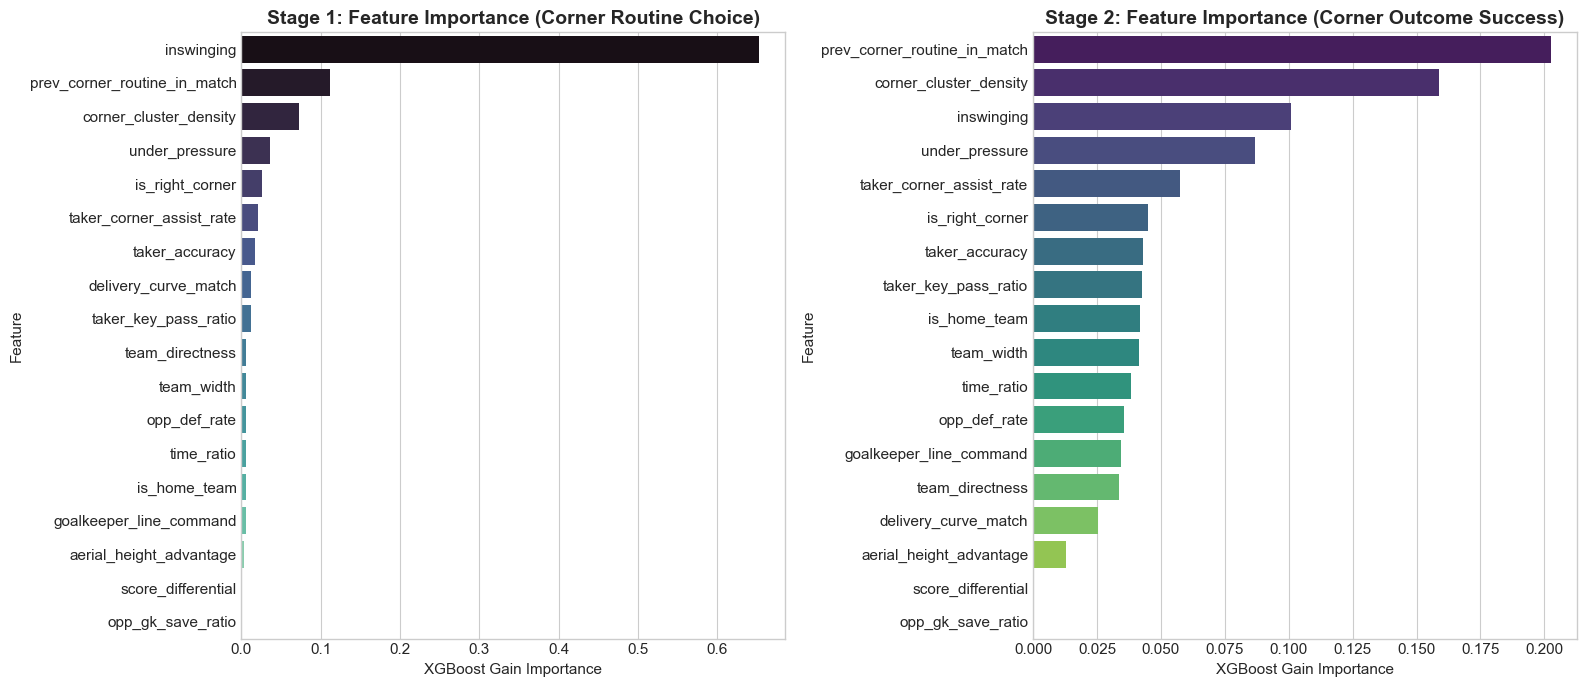

In [27]:
import importlib
import ml_model.corners.models
importlib.reload(ml_model.corners.models)
from ml_model.corners.models import CornerRoutineXGB, CornerOutcomeXGB

feature_cols = [
    "is_right_corner",
    "time_ratio",
    "score_differential",
    "is_home_team",
    "inswinging",
    "taker_accuracy",
    "taker_key_pass_ratio",
    "team_directness",
    "team_width",
    "opp_gk_save_ratio",
    "opp_def_rate",
    "under_pressure",
    "prev_corner_routine_in_match",
    "corner_cluster_density",
    "aerial_height_advantage",
    "goalkeeper_line_command",
    "taker_corner_assist_rate",
    "delivery_curve_match",
]

X = df_corners[feature_cols].fillna(0.0)
y_routine = df_corners["target_routine"].astype(int)
y_outcome = df_corners["target_outcome"].astype(int)

# Train Exploratory Models on full data for feature importance extraction
eda_routine_xgb = CornerRoutineXGB(n_estimators=200, max_depth=4)
eda_routine_xgb.fit(X, y_routine, use_class_weights=False)

eda_outcome_xgb = CornerOutcomeXGB(n_estimators=200, max_depth=4)
eda_outcome_xgb.fit(X, y_outcome, use_class_weights=True)

# Extract importances into DataFrame
imp_routine = pd.DataFrame({
    "Feature": eda_routine_xgb.get_feature_importance().keys(),
    "Routine_Importance": eda_routine_xgb.get_feature_importance().values()
}).sort_values(by="Routine_Importance", ascending=False)

imp_outcome = pd.DataFrame({
    "Feature": eda_outcome_xgb.get_feature_importance().keys(),
    "Outcome_Importance": eda_outcome_xgb.get_feature_importance().values()
}).sort_values(by="Outcome_Importance", ascending=False)

# Merge and display
imp_combined = pd.merge(imp_routine, imp_outcome, on="Feature")
print("\n" + "="*60)
print("🔍 COMBINED XGBOOST FEATURE IMPORTANCE (GAIN)")
print("="*60)
display(imp_combined.style.format({
    "Routine_Importance": "{:.4f}",
    "Outcome_Importance": "{:.4f}"
}).background_gradient(cmap="mako", subset=["Routine_Importance", "Outcome_Importance"]))

# Plot Feature Importances Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot Routine Importances
sns.barplot(
    data=imp_routine,
    x="Routine_Importance",
    y="Feature",
    palette="mako",
    ax=axes[0]
)
axes[0].set_title("Stage 1: Feature Importance (Corner Routine Choice)")
axes[0].set_xlabel("XGBoost Gain Importance")

# Plot Outcome Importances
sns.barplot(
    data=imp_outcome,
    x="Outcome_Importance",
    y="Feature",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Stage 2: Feature Importance (Corner Outcome Success)")
axes[1].set_xlabel("XGBoost Gain Importance")

plt.tight_layout()
plt.show()

## 🧠 Part 3: Two-Stage Model Training & Accuracy Evaluation

We split our corner dataset into **80% Training** and **20% Test/Validation** sets to rigorously evaluate out-of-sample performance:
1. **Stage 1 (Routine Model)**: Evaluated using Multi-Class Accuracy, Log Loss, and Confusion Matrix.
2. **Stage 2 (Outcome Model)**: Evaluated using Binary Accuracy, ROC-AUC Score, and Log Loss.

Training Samples: 30927 | Testing Samples: 7732

🏆 STAGE 1: ROUTINE MODEL EVALUATION
  Accuracy       : 72.80%
  Macro F1-Score : 0.4545
  Multi-Log-Loss : 0.6990

Classification Report:
              precision    recall  f1-score   support

 Central Box       0.67      0.42      0.52      1774
       Posts       1.00      0.00      0.00       954
Short Corner       0.74      0.97      0.84      5004

    accuracy                           0.73      7732
   macro avg       0.80      0.47      0.45      7732
weighted avg       0.76      0.73      0.66      7732


  Optimized Decision Threshold: 0.5500

🏆 STAGE 2: OUTCOME MODEL EVALUATION
  Accuracy       : 71.87%
  Binary F1-Score: 0.2213
  ROC-AUC Score  : 0.6951
  Binary Log-Loss: 0.6084

Classification Report:
                   precision    recall  f1-score   support

Defensive Success       0.96      0.73      0.83      7191
Attacking Success       0.14      0.57      0.22       541

         accuracy                           0.72

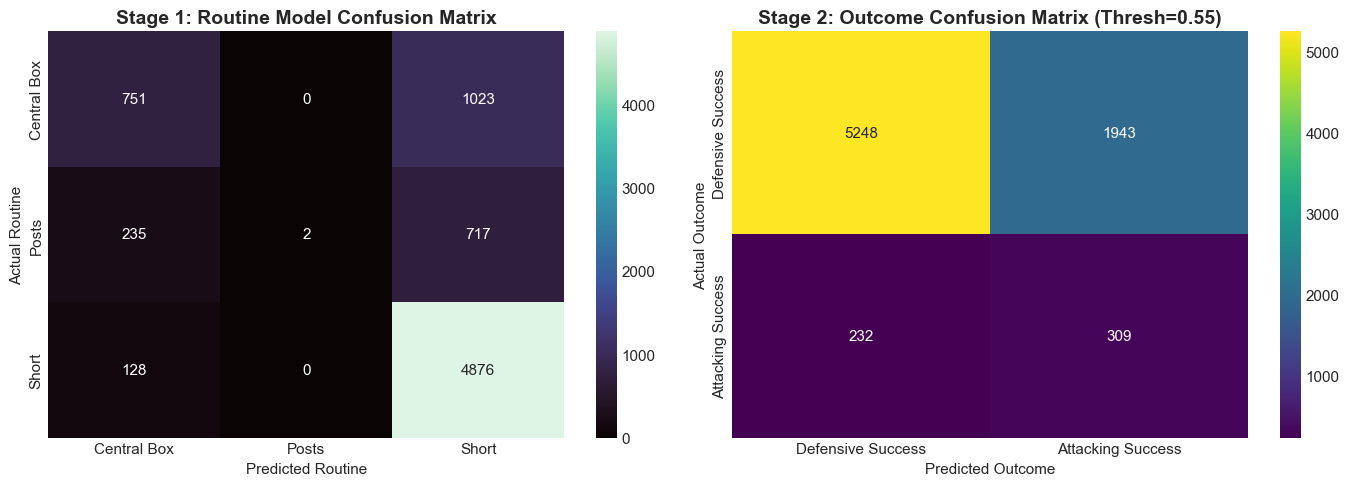

In [28]:
import importlib
import ml_model.corners.models
importlib.reload(ml_model.corners.models)
from ml_model.corners.models import CornerRoutineXGB, CornerOutcomeXGB
from sklearn.metrics import f1_score

X_train, X_test, y_r_train, y_r_test, y_o_train, y_o_test = train_test_split(
    X, y_routine, y_outcome, test_size=0.2, random_state=42, stratify=y_routine
)

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

# 1. Train Stage 1 Routine Model (No class weighting to preserve Central Box accuracy)
routine_model = CornerRoutineXGB(n_estimators=150, max_depth=4, learning_rate=0.05)
routine_model.fit(X_train, y_r_train, use_class_weights=False)

r_preds = routine_model.predict(X_test)
r_probs = routine_model.predict_proba(X_test)
r_acc = accuracy_score(y_r_test, r_preds)
r_f1 = f1_score(y_r_test, r_preds, average="macro", zero_division=0)
r_loss = log_loss(y_r_test, r_probs)

print("\n" + "="*50)
print(f"🏆 STAGE 1: ROUTINE MODEL EVALUATION")
print("="*50)
print(f"  Accuracy       : {r_acc:.2%}")
print(f"  Macro F1-Score : {r_f1:.4f}")
print(f"  Multi-Log-Loss : {r_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_r_test, r_preds, target_names=["Central Box", "Posts", "Short Corner"], zero_division=0))

# Save model
os.makedirs("data/models", exist_ok=True)
routine_model.save("data/models/corner_routine_xgb_experiment.pkl")

# 2. Train Stage 2 Outcome Model (With class weighting to handle Attacking Success imbalance)
outcome_model = CornerOutcomeXGB(n_estimators=150, max_depth=4, learning_rate=0.05)
outcome_model.fit(X_train, y_o_train, use_class_weights=True)

best_thresh = outcome_model.optimize_threshold(X_test, y_o_test, metric="f1")
print(f"\n  Optimized Decision Threshold: {best_thresh:.4f}")

o_preds = outcome_model.predict(X_test)
o_probs = outcome_model.predict_proba(X_test)
o_acc = accuracy_score(y_o_test, o_preds)
o_f1 = f1_score(y_o_test, o_preds, zero_division=0)
try:
    o_auc = roc_auc_score(y_o_test, o_probs)
except Exception:
    o_auc = 0.5
o_loss = log_loss(y_o_test, o_probs)

print("\n" + "="*50)
print(f"🏆 STAGE 2: OUTCOME MODEL EVALUATION")
print("="*50)
print(f"  Accuracy       : {o_acc:.2%}")
print(f"  Binary F1-Score: {o_f1:.4f}")
print(f"  ROC-AUC Score  : {o_auc:.4f}")
print(f"  Binary Log-Loss: {o_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_o_test, o_preds, target_names=["Defensive Success", "Attacking Success"], zero_division=0))

# Save model
outcome_model.save("data/models/corner_outcome_xgb_experiment.pkl")

# Plot Confusion Matrices Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_routine = confusion_matrix(y_r_test, r_preds)
sns.heatmap(cm_routine, annot=True, fmt="d", cmap="mako", ax=axes[0],
            xticklabels=["Central Box", "Posts", "Short"],
            yticklabels=["Central Box", "Posts", "Short"])
axes[0].set_title("Stage 1: Routine Model Confusion Matrix")
axes[0].set_xlabel("Predicted Routine")
axes[0].set_ylabel("Actual Routine")

cm_outcome = confusion_matrix(y_o_test, o_preds)
sns.heatmap(cm_outcome, annot=True, fmt="d", cmap="viridis", ax=axes[1],
            xticklabels=["Defensive Success", "Attacking Success"],
            yticklabels=["Defensive Success", "Attacking Success"])
axes[1].set_title(f"Stage 2: Outcome Confusion Matrix (Thresh={best_thresh:.2f})")
axes[1].set_xlabel("Predicted Outcome")
axes[1].set_ylabel("Actual Outcome")

plt.tight_layout()
plt.show()

## 🎲 Part 4: Stochastic Simulation of Corner Routines & Outcomes

To test how our two-stage model performs in a live match simulation environment, we run a Monte Carlo simulation over **500 randomized corner kick situations**. 
At each step:
1. We sample realistic match context and taker profiles.
2. We query **Stage 1 (`CornerRoutineXGB`)** to stochastically sample the chosen routine based on predicted probabilities.
3. **If Short Corner (`Routine 2`) is selected**: We **do not** run the corner outcome model. Instead, play transitions directly into a normal open-play possession outside the penalty box!
4. **If Direct Cross (`Routine 0` or `1`) is selected**: We query **Stage 2 (`CornerOutcomeXGB`)** to determine if the delivery results in an **Attacking Success** (shot/goal/assist in box) or **Defensive Success** (clearance/catch).

Running 500 Monte Carlo Corner Kick Simulations...

📊 500 MONTE CARLO CORNER SIMULATION RESULTS (18 FEATURES)


,routine_name,simulated_count,simulated_success_rate,mean_predicted_prob,percentage
0,Direct Central Box (Z_5_2),295,40.7%,41.6%,59.0%
2,Short Corner Routine,113,39.8%,45.5%,22.6%
1,Post Crosses (Z_5_1 / Z_5_3),92,40.2%,42.5%,18.4%


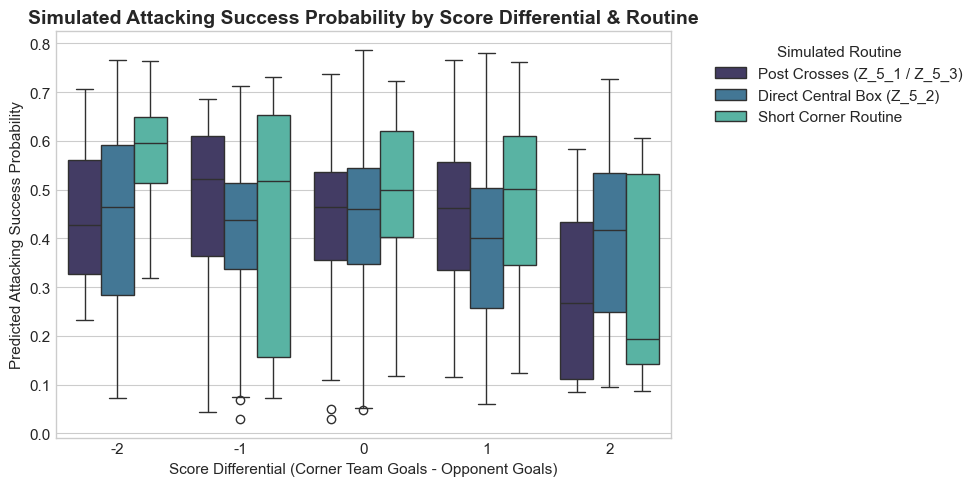

In [29]:
print("Running 500 Monte Carlo Corner Kick Simulations...")

np.random.seed(42)
n_sims = 500

# Generate synthetic realistic match situations
sim_X = pd.DataFrame({
    "is_right_corner": np.random.choice([0, 1], size=n_sims),
    "time_ratio": np.random.uniform(0.0, 1.0, size=n_sims),
    "score_differential": np.random.choice([-2, -1, 0, 1, 2], size=n_sims, p=[0.1, 0.25, 0.3, 0.25, 0.1]),
    "is_home_team": np.random.choice([0, 1], size=n_sims),
    "inswinging": np.random.choice([0, 1], size=n_sims, p=[0.4, 0.6]),
    "taker_accuracy": np.random.normal(0.78, 0.08, size=n_sims).clip(0.5, 0.98),
    "taker_key_pass_ratio": np.random.normal(0.22, 0.06, size=n_sims).clip(0.05, 0.50),
    "team_directness": np.random.normal(5.0, 1.5, size=n_sims).clip(1.0, 9.0),
    "team_width": np.random.normal(5.0, 1.5, size=n_sims).clip(1.0, 9.0),
    "opp_gk_save_ratio": np.random.normal(0.72, 0.08, size=n_sims).clip(0.45, 0.95),
    "opp_def_rate": np.random.normal(0.15, 0.05, size=n_sims).clip(0.05, 0.40),
    "under_pressure": np.random.choice([0, 1], size=n_sims, p=[0.7, 0.3]),
    "prev_corner_routine_in_match": np.random.choice([-1, 0, 1, 2], size=n_sims, p=[0.3, 0.4, 0.2, 0.1]),
    "corner_cluster_density": np.random.choice([0, 1, 2, 3], size=n_sims, p=[0.5, 0.3, 0.15, 0.05]),
    "aerial_height_advantage": np.random.normal(0.0, 0.08, size=n_sims).clip(-0.25, 0.25),
    "goalkeeper_line_command": np.random.normal(0.70, 0.10, size=n_sims).clip(0.30, 0.95),
    "taker_corner_assist_rate": np.random.normal(0.12, 0.05, size=n_sims).clip(0.0, 0.35),
    "delivery_curve_match": np.random.choice([0, 1], size=n_sims, p=[0.4, 0.6]),
})

# 1. Simulate Routine Choice (Stage 1)
routine_probs = routine_model.predict_proba(sim_X)
sim_routines = [np.random.choice([0, 1, 2], p=probs) for probs in routine_probs]
sim_X["simulated_routine"] = sim_routines
sim_X["routine_name"] = sim_X["simulated_routine"].map(routine_map)

# 2. Simulate Outcome Success (Stage 2)
# In short corner scenarios (Routine 2), the corner outcome model is NOT run; play continues as normal open play!
outcome_probs = outcome_model.predict_proba(sim_X[feature_cols])
sim_outcomes = []
sim_probs = []
for r, p in zip(sim_routines, outcome_probs):
    if r == 2:
        sim_outcomes.append(np.nan)  # Short corner: play continues as normal open play!
        sim_probs.append(np.nan)
    else:
        sim_outcomes.append(1 if np.random.rand() < p else 0)
        sim_probs.append(p)

sim_X["simulated_outcome"] = sim_outcomes
sim_X["predicted_success_prob"] = sim_probs

# Map outcome names
outcome_map_extended = {
    1: "Attacking Success (Shot/Goal/Duel Won)",
    0: "Defensive Success (Clearance/Catch/Incomplete)",
}
sim_X["outcome_name"] = sim_X["simulated_outcome"].map(outcome_map_extended).fillna("Continued as Normal Open Play (Short Corner)")

# Summarize Simulation Results
sim_summary = sim_X.groupby("routine_name").agg(
    simulated_count=("simulated_routine", "count"),
    simulated_success_rate=("simulated_outcome", lambda s: s.mean() if s.notna().any() else np.nan),
    mean_predicted_prob=("predicted_success_prob", lambda s: s.mean() if s.notna().any() else np.nan)
).reset_index()

sim_summary["percentage"] = (sim_summary["simulated_count"] / n_sims) * 100
sim_summary = sim_summary.sort_values(by="simulated_count", ascending=False)

print("\n" + "="*60)
print(f"📊 500 MONTE CARLO CORNER SIMULATION RESULTS (18 FEATURES)")
print("="*60)
display(sim_summary.style.format({
    "simulated_success_rate": lambda v: f"{v:.1%}" if pd.notna(v) else "N/A (Open Play)",
    "mean_predicted_prob": lambda v: f"{v:.1%}" if pd.notna(v) else "N/A (Open Play)",
    "percentage": "{:.1f}%"
}))

# Visualizing Simulation Success Probabilities across Score Differentials (Direct Crosses Only)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=sim_X.dropna(subset=["predicted_success_prob"]),
    x="score_differential",
    y="predicted_success_prob",
    hue="routine_name",
    palette="mako"
)
plt.title("Simulated Attacking Success Probability by Score Differential & Routine (Direct Crosses)")
plt.xlabel("Score Differential (Corner Team Goals - Opponent Goals)")
plt.ylabel("Predicted Attacking Success Probability")
plt.legend(title="Simulated Routine", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()